In [25]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


# 1. SETUP

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

# 2. CONFIG

In [27]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Sesuaikan kemampuan GPU

TRAIN_DIR = "data/processed/train"
VAL_DIR   = "data/processed/validation"
TEST_DIR  = "data/processed/test"

EPOCHS = 30 # Bisa diubah
FINE_TUNE_EPOCHS = 15 # Epoch untuk fine-tuning

INITIAL_LR = 1e-4 # Learning rate di 0.0001
FINE_TUNE_LR = 1e-5 # Learning rate di 0.00001 untuk fine-tuning

# Kontrol training: default jalankan full epoch (tanpa stop otomatis)
USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 7
EARLY_STOP_START_EPOCH = 3

# 3. LOAD DATASET

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalisasi dataset ke rentang [0, 1] sebelum masuk ke model
train_gen = ImageDataGenerator(rescale=1.0 / 255.0)
val_test_gen = ImageDataGenerator(rescale=1.0 / 255.0)

# Membuat generator untuk data train
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data validasi
val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data test
test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 560 images belonging to 4 classes.
Found 60 images belonging to 4 classes.


Found 60 images belonging to 4 classes.


# 4. CALLBACK

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("models/best_model.h5", save_best_only=True),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

# EarlyStopping opsional: aktifkan jika ingin hentikan training otomatis
if USE_EARLY_STOPPING:
    callbacks.append(
        EarlyStopping(
            monitor='val_loss',
            patience=EARLY_STOP_PATIENCE,
            start_from_epoch=EARLY_STOP_START_EPOCH,
            restore_best_weights=True,
            verbose=1,
        )
    )

# 5. FUNCTION EVALUASI

In [ ]:
def _collect_full_test_set(generator):
    generator.reset()
    x_batches, y_batches = [], []
    for _ in range(len(generator)):
        x_batch, y_batch = next(generator)
        x_batches.append(x_batch)
        y_batches.append(y_batch)

    x_test = np.concatenate(x_batches, axis=0)
    y_true = np.argmax(np.concatenate(y_batches, axis=0), axis=1)
    return x_test, y_true

def evaluate_model(model, model_name, return_details=False, show_plot=True):
    print(f"\n=== {model_name} ===")

    # Evaluasi loss/akurasi pada test generator
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose=0)
    print("Accuracy:", acc)
    print("Loss:", loss)

    # Prediksi menggunakan array penuh agar bentuk tensor konsisten
    x_test, y_true = _collect_full_test_set(test_data)
    y_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    class_names = [
        name
        for name, _ in sorted(test_data.class_indices.items(), key=lambda item: item[1])
    ]

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    print("\nClassification Report:")
    print(report_text)

    cm = confusion_matrix(y_true, y_pred)
    if show_plot:
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    if return_details:
        return {
            "model_name": model_name,
            "accuracy": float(acc),
            "loss": float(loss),
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "class_names": class_names,
            "report_dict": report_dict,
            "confusion_matrix": cm,
        }

    return acc

# 6. MODEL

## A. MobileNetV2

In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Membangun MobileNetV2 sebagai base model
def build_mobilenet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    # Data sudah dinormalisasi [0, 1], kembalikan ke [0, 255] sebelum preprocess_input
    x = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)

    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## B. EfficientNetB0

In [32]:
from tensorflow.keras.applications import EfficientNetB0

# Membangun EfficientNetB0 sebagai base model
def build_efficientnet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    x = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## C. Hybrid (Feature Fusion)

In [33]:
def build_fusion():
    input_layer = tf.keras.Input(shape=(224, 224, 3))

    # Dataset sudah [0,1], ubah dulu ke [0,255] agar preprocessing backbone sesuai
    mob_in = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)
    eff_in = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base1 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mob_in)
    base2 = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=eff_in)

    base1.trainable = False
    base2.trainable = False

    x1 = layers.GlobalAveragePooling2D()(base1.output)
    x1 = layers.BatchNormalization()(x1)

    x2 = layers.GlobalAveragePooling2D()(base2.output)
    x2 = layers.BatchNormalization()(x2)

    fusion = layers.concatenate([x1, x2])

    x = layers.Dense(256, activation='relu')(fusion)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base1, base2

# 7. Training Function (2 Tahap)

In [ ]:
import time

def train_model(model, base_model=None):
    # Tahap 1
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    stage1_start = time.perf_counter()
    history_stage1 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=callbacks
    )
    stage1_time = time.perf_counter() - stage1_start

    # Tahap 2 (Fine-tuning)
    if base_model is not None:
        base_model.trainable = True
        for layer in base_model.layers[:-80]:
            layer.trainable = False
        for layer in base_model.layers[-80:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    stage2_start = time.perf_counter()
    history_stage2 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks
    )
    stage2_time = time.perf_counter() - stage2_start

    history_bundle = {
        "stage1": history_stage1.history,
        "stage2": history_stage2.history,
    }
    timing_bundle = {
        "stage1_sec": stage1_time,
        "stage2_sec": stage2_time,
        "total_sec": stage1_time + stage2_time,
    }

    return model, history_bundle, timing_bundle

# 8. Train & Evaluasi Model

## A. MobileNetV2

C:\Users\rifqi\AppData\Local\Temp\ipykernel_5440\528472138.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.3123 - loss: 1.9866

18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 775ms/step - accuracy: 0.3446 - loss: 1.8722 - val_accuracy: 0.6167 - val_loss: 1.1058 - learning_rate: 1.0000e-04
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.4151 - loss: 1.4472

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 343ms/step - accuracy: 0.4536 - loss: 1.3491 - val_accuracy: 0.7167 - val_loss: 0.9033 - learning_rate: 1.0000e-04
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.5635 - loss: 1.0825

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 339ms/step - accuracy: 0.5714 - loss: 1.0571 - val_accuracy: 0.7667 - val_loss: 0.7828 - learning_rate: 1.0000e-04
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.6159 - loss: 0.9808

...

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 355ms/step - accuracy: 0.9054 - loss: 0.2420 - val_accuracy: 0.8667 - val_loss: 0.3707 - learning_rate: 1.0000e-04
Epoch 27/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9017 - loss: 0.2464

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step - accuracy: 0.9089 - loss: 0.2308 - val_accuracy: 0.8667 - val_loss: 0.3643 - learning_rate: 1.0000e-04
Epoch 28/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.9257 - loss: 0.2178

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 345ms/step - accuracy: 0.9286 - loss: 0.2201 - val_accuracy: 0.8667 - val_loss: 0.3635 - learning_rate: 1.0000e-04
Epoch 29/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9202 - loss: 0.1946

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 346ms/step - accuracy: 0.9250 - loss: 0.2014 - val_accuracy: 0.8667 - val_loss: 0.3615 - learning_rate: 1.0000e-04
Epoch 30/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9405 - loss: 0.1680

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 344ms/step - accuracy: 0.9339 - loss: 0.1858 - val_accuracy: 0.8667 - val_loss: 0.3604 - learning_rate: 1.0000e-04
Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.6429 - loss: 0.9244 - val_accuracy: 0.8500 - val_loss: 0.3737 - learning_rate: 1.0000e-05
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 922ms/step - accuracy: 0.7286 - loss: 0.7284 - val_accuracy: 0.8333 - val_loss: 0.3840 - learning_rate: 1.0000e-05
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.7251 - loss: 0.6849
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 871ms/step - accuracy: 0.7018 - loss: 0.7569 - val_accuracy: 0.8333 - val_loss: 0.3870 - learning_rate: 1.0000e-05
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 633ms/step - accuracy: 0.7607 - loss: 0.6251 - val_accuracy: 0.8000 - val_loss: 0.3929 - learning_rate: 5.0000e-06
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 605ms/step - accuracy: 0.7625 - loss:

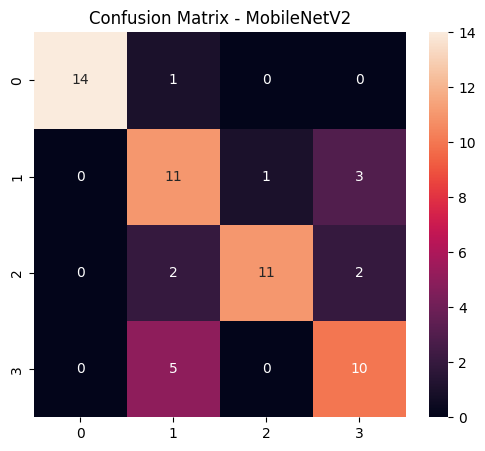

In [35]:
model_m, base_m = build_mobilenet()
model_m, history_m, timing_m = train_model(model_m, base_m)
eval_m = evaluate_model(model_m, "MobileNetV2", return_details=True)
acc_m = eval_m["accuracy"]

## B. EfficientNetB0

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 652ms/step - accuracy: 0.2964 - loss: 1.9953 - val_accuracy: 0.4167 - val_loss: 1.2571 - learning_rate: 1.0000e-04
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 467ms/step - accuracy: 0.4286 - loss: 1.4887 - val_accuracy: 0.5833 - val_loss: 1.0948 - learning_rate: 1.0000e-04
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.5571 - loss: 1.2131
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 468ms/step - accuracy: 0.5536 - loss: 1.1861 - val_accuracy: 0.7000 - val_loss: 0.9609 - learning_rate: 1.0000e-04
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 473ms/step - accuracy: 0.6107 - loss: 1.0301 - val_accuracy: 0.7333 - val_loss: 0.8893 - learning_rate: 5.0000e-05
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.6196 - loss: 0.9545 - val_accuracy: 0.7500 - val_loss: 0.8239 - learning_rate: 5.0000e-05
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.64

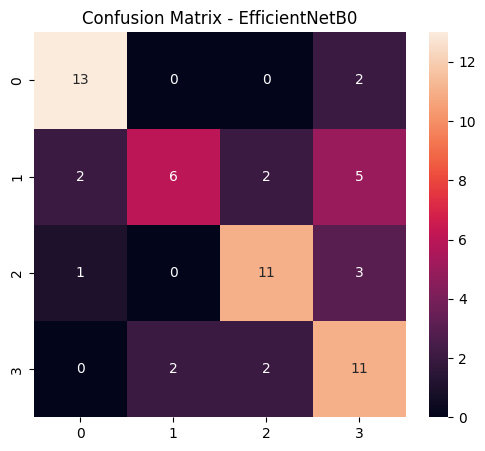

In [36]:
model_e, base_e = build_efficientnet()
model_e, history_e, timing_e = train_model(model_e, base_e)
eval_e = evaluate_model(model_e, "EfficientNetB0", return_details=True)
acc_e = eval_e["accuracy"]

## C. Hybrid Model

C:\Users\rifqi\AppData\Local\Temp\ipykernel_5440\3286220957.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base1 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mob_in)


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 37s 900ms/step - accuracy: 0.4500 - loss: 1.6114 - val_accuracy: 0.6500 - val_loss: 0.8933 - learning_rate: 1.0000e-04
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 679ms/step - accuracy: 0.6679 - loss: 0.8941 - val_accuracy: 0.7833 - val_loss: 0.6851 - learning_rate: 1.0000e-04
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.7918 - loss: 0.5992
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 681ms/step - accuracy: 0.7714 - loss: 0.6381 - val_accuracy: 0.8500 - val_loss: 0.5795 - learning_rate: 1.0000e-04
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 688ms/step - accuracy: 0.8036 - loss: 0.5111 - val_accuracy: 0.8167 - val_loss: 0.5366 - learning_rate: 5.0000e-05
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 689ms/step - accuracy: 0.8321 - loss: 0.4294 - val_accuracy: 0.8000 - val_loss: 0.5056 - learning_rate: 5.0000e-05
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 

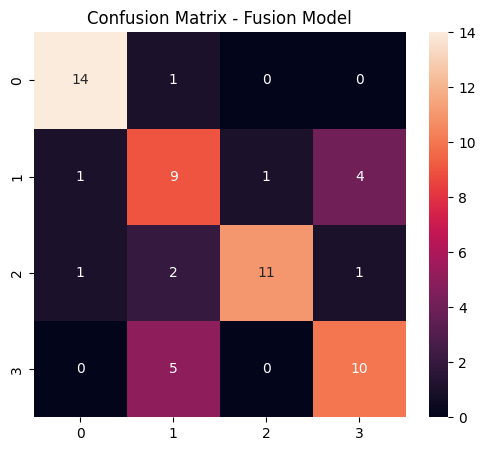

In [37]:
model_f, base1, base2 = build_fusion()

# Tahap 1
model_f.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
 )
hybrid_stage1_start = time.perf_counter()
history_f_stage1 = model_f.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
 )
hybrid_stage1_time = time.perf_counter() - hybrid_stage1_start

# Fine-tuning dua backbone
for layer in base1.layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
for layer in base2.layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model_f.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
 )
hybrid_stage2_start = time.perf_counter()
history_f_stage2 = model_f.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks
 )
hybrid_stage2_time = time.perf_counter() - hybrid_stage2_start

history_f = {
    "stage1": history_f_stage1.history,
    "stage2": history_f_stage2.history,
}
timing_f = {
    "stage1_sec": hybrid_stage1_time,
    "stage2_sec": hybrid_stage2_time,
    "total_sec": hybrid_stage1_time + hybrid_stage2_time,
}

eval_f = evaluate_model(model_f, "Fusion Model", return_details=True)
acc_f = eval_f["accuracy"]

# 9. Perbandingan Hasil

In [38]:
print("\n=== HASIL AKHIR ===")
print(f"MobileNetV2   : {acc_m}")
print(f"EfficientNet  : {acc_e}")
print(f"Fusion Model  : {acc_f}")


=== HASIL AKHIR ===
MobileNetV2   : 0.7666666507720947
EfficientNet  : 0.6833333373069763
Fusion Model  : 0.7333333492279053


# 10. Visualisasi Hasil dan Performa 3 Model

Info: history_* belum ada, grafik accuracy/loss curve tidak ditampilkan.
Info: timing_* belum ada, perbandingan waktu training tidak ditampilkan.


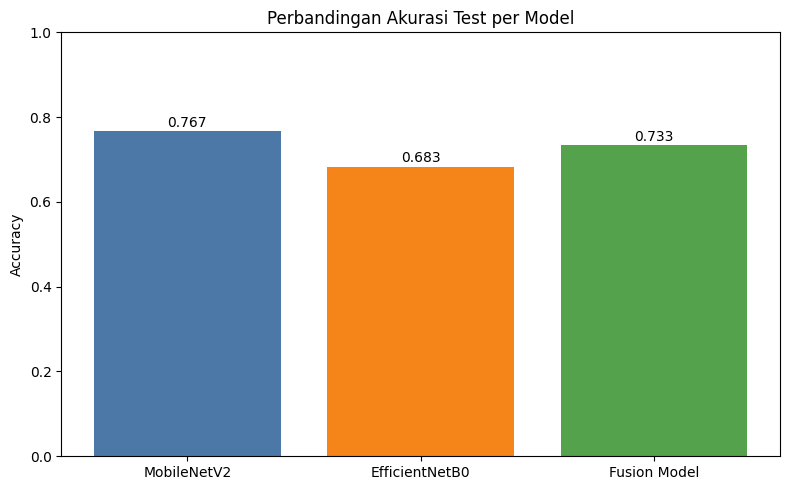

Model akurasi tertinggi: MobileNetV2 (0.7667)
Peningkatan Hybrid vs MobileNetV2: -3.33%


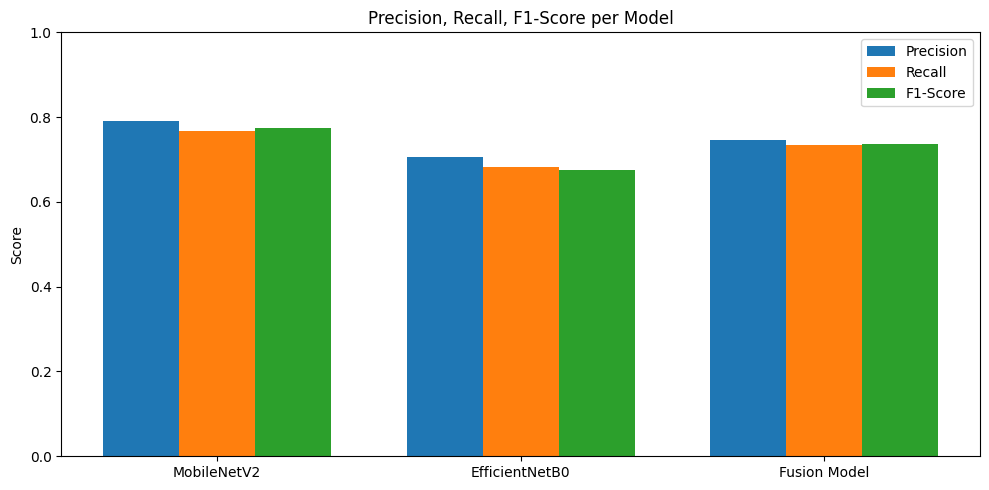

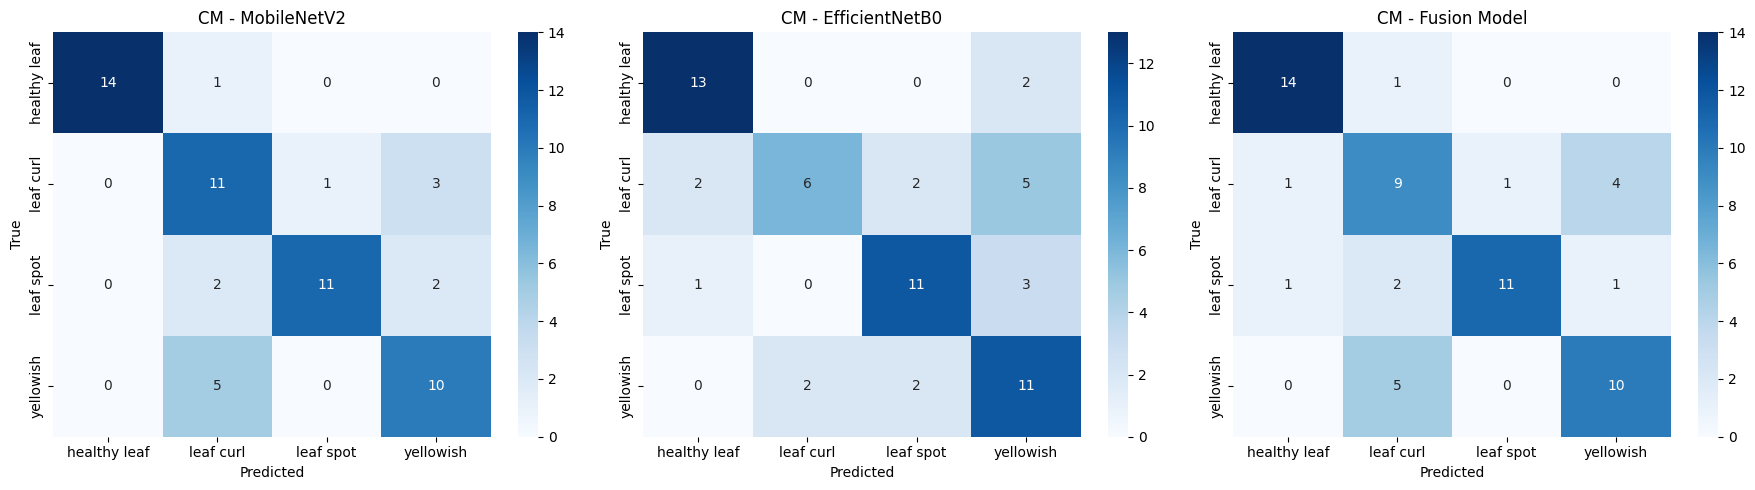

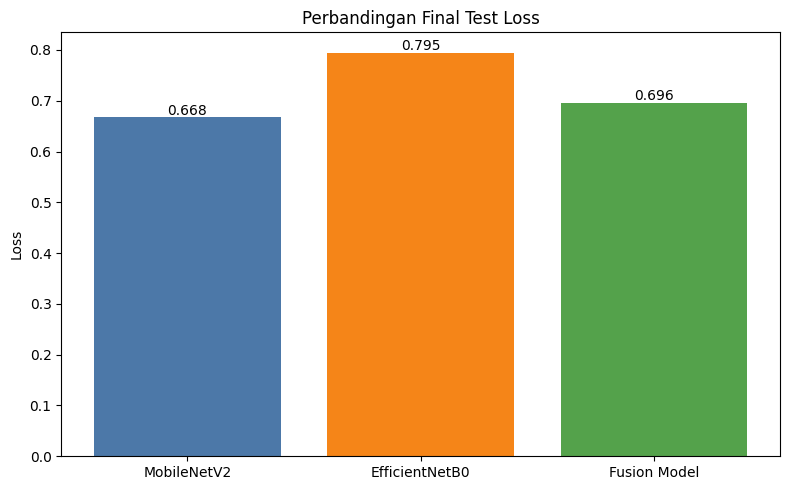

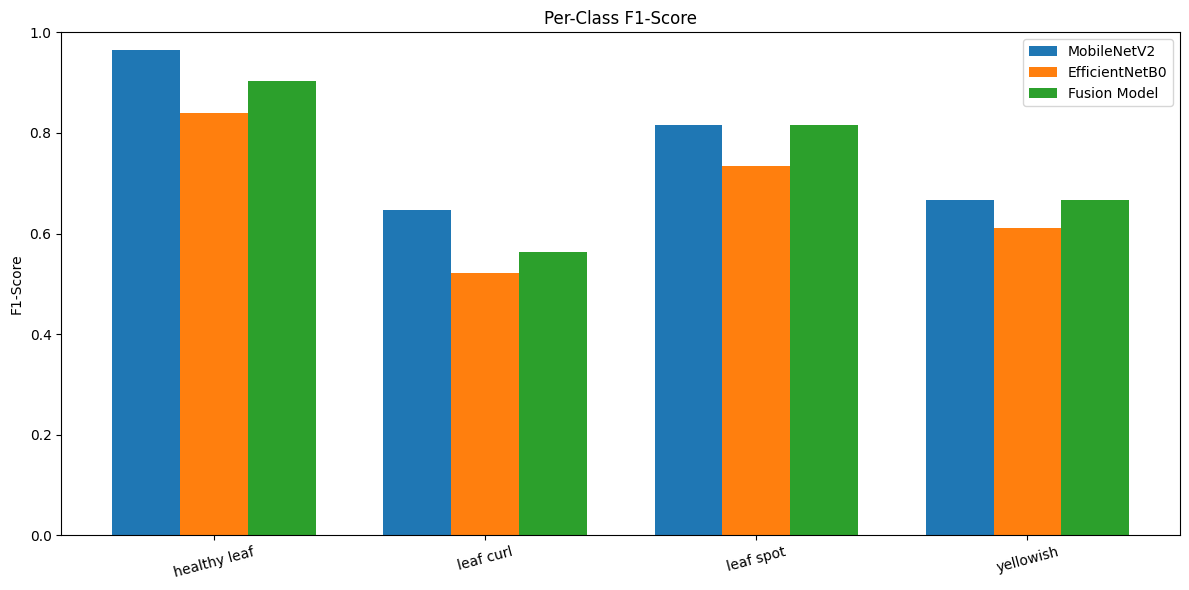

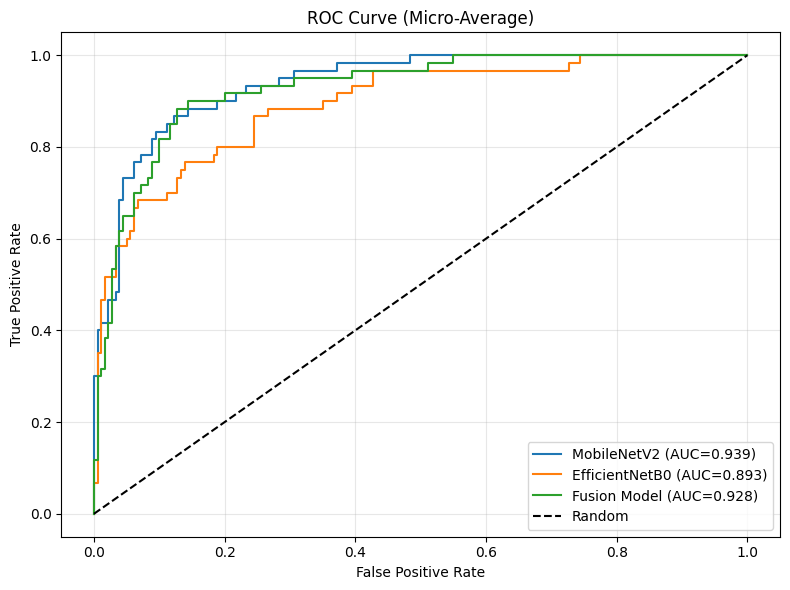

,Model,Accuracy,Precision,Recall,F1-Score,Test Loss,AUC,Training Time (sec)
0,MobileNetV2,0.7667,0.7906,0.7667,0.7735,0.6676,0.9388,NaN
2,Fusion Model,0.7333,0.7469,0.7333,0.7368,0.6965,0.9281,NaN
1,EfficientNetB0,0.6833,0.7049,0.6833,0.6762,0.7949,0.8931,NaN


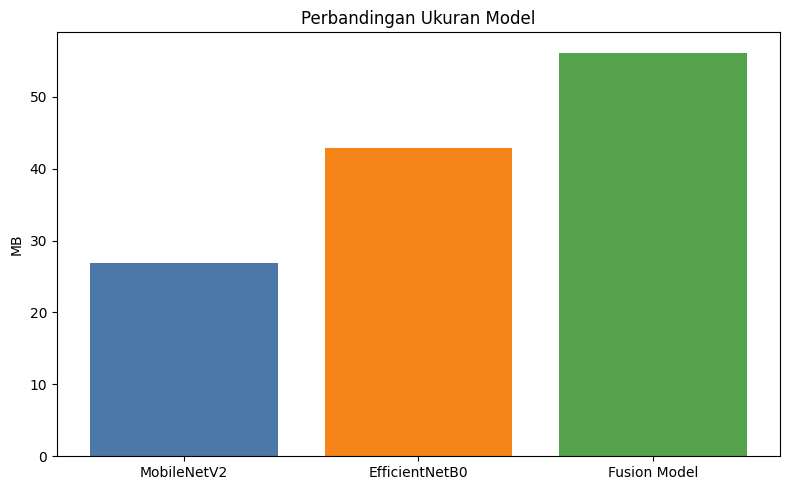


Insight cepat:
- Akurasi tertinggi: MobileNetV2
- Gain Hybrid vs MobileNetV2: -3.33%
- Cek gap train vs validation untuk indikasi overfitting.
- Cek confusion matrix untuk kelas yang masih sering tertukar.


In [42]:
import pandas as pd
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

# Pastikan model tersedia di kernel
required_models = ["model_m", "model_e", "model_f"]
missing_models = [name for name in required_models if name not in globals()]
if missing_models:
    raise ValueError(
        "Model belum tersedia di kernel. Jalankan dulu cell 23, 25, dan 27. "
        f"Missing: {missing_models}"
    )

def build_eval_details(model, model_name):
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose=0)

    test_data.reset()
    x_batches, y_batches = [], []
    for _ in range(len(test_data)):
        x_batch, y_batch = next(test_data)
        x_batches.append(x_batch)
        y_batches.append(y_batch)

    x_test = np.concatenate(x_batches, axis=0)
    y_true = np.argmax(np.concatenate(y_batches, axis=0), axis=1)
    y_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    class_names_local = [
        name for name, _ in sorted(test_data.class_indices.items(), key=lambda item: item[1])
    ]

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names_local,
        zero_division=0,
        output_dict=True,
    )
    cm = confusion_matrix(y_true, y_pred)

    return {
        "model_name": model_name,
        "accuracy": float(acc),
        "loss": float(loss),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "class_names": class_names_local,
        "report_dict": report_dict,
        "confusion_matrix": cm,
    }

# Jika detail evaluasi belum ada, hitung otomatis
if "eval_m" not in globals():
    eval_m = build_eval_details(model_m, "MobileNetV2")
if "eval_e" not in globals():
    eval_e = build_eval_details(model_e, "EfficientNetB0")
if "eval_f" not in globals():
    eval_f = build_eval_details(model_f, "Fusion Model")

model_results = {
    "MobileNetV2": eval_m,
    "EfficientNetB0": eval_e,
    "Fusion Model": eval_f,
}

history_available = all(name in globals() for name in ["history_m", "history_e", "history_f"])
timing_available = all(name in globals() for name in ["timing_m", "timing_e", "timing_f"])

if history_available:
    model_histories = {
        "MobileNetV2": history_m,
        "EfficientNetB0": history_e,
        "Fusion Model": history_f,
    }
else:
    print("Info: history_* belum ada, grafik accuracy/loss curve tidak ditampilkan.")

if timing_available:
    model_timings = {
        "MobileNetV2": timing_m,
        "EfficientNetB0": timing_e,
        "Fusion Model": timing_f,
    }
else:
    print("Info: timing_* belum ada, perbandingan waktu training tidak ditampilkan.")

class_names = eval_m["class_names"]

def merge_history(history_bundle):
    train_acc = history_bundle["stage1"].get("accuracy", []) + history_bundle["stage2"].get("accuracy", [])
    val_acc = history_bundle["stage1"].get("val_accuracy", []) + history_bundle["stage2"].get("val_accuracy", [])
    train_loss = history_bundle["stage1"].get("loss", []) + history_bundle["stage2"].get("loss", [])
    val_loss = history_bundle["stage1"].get("val_loss", []) + history_bundle["stage2"].get("val_loss", [])
    return train_acc, val_acc, train_loss, val_loss

def get_model_size_mb(model, filename):
    model.save(filename, include_optimizer=False)
    size_mb = os.path.getsize(filename) / (1024 ** 2)
    os.remove(filename)
    return size_mb

# 1) Perbandingan Akurasi per Model
acc_df = pd.DataFrame({
    "Model": list(model_results.keys()),
    "Accuracy": [v["accuracy"] for v in model_results.values()],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.show()

best_model = acc_df.sort_values("Accuracy", ascending=False).iloc[0]
hybrid_gain_vs_mobilenet = (model_results["Fusion Model"]["accuracy"] - model_results["MobileNetV2"]["accuracy"]) * 100
print(f"Model akurasi tertinggi: {best_model['Model']} ({best_model['Accuracy']:.4f})")
print(f"Peningkatan Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")

# 2) Precision, Recall, F1-Score per Model
metric_rows = []
for model_name, result in model_results.items():
    w = result["report_dict"]["weighted avg"]
    metric_rows.append({
        "Model": model_name,
        "Precision": w["precision"],
        "Recall": w["recall"],
        "F1-Score": w["f1-score"],
    })
metrics_df = pd.DataFrame(metric_rows)

x = np.arange(len(metrics_df))
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, metrics_df["Precision"], width=w, label="Precision")
plt.bar(x, metrics_df["Recall"], width=w, label="Recall")
plt.bar(x + w, metrics_df["F1-Score"], width=w, label="F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Confusion Matrix (3 heatmap)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, result) in zip(axes, model_results.items()):
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(f"CM - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

# 4) Training vs Validation Accuracy Curve
if history_available:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()):
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        ax.plot(epochs, train_acc, label="Train Accuracy")
        ax.plot(epochs, val_acc, label="Validation Accuracy")
        ax.set_title(f"Accuracy Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

# 5) Training vs Validation Loss Curve
if history_available:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()):
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        ax.plot(epochs, train_loss, label="Train Loss")
        ax.plot(epochs, val_loss, label="Validation Loss")
        ax.set_title(f"Loss Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

# 6) Perbandingan Loss Akhir
loss_df = pd.DataFrame({
    "Model": list(model_results.keys()),
    "Final Test Loss": [v["loss"] for v in model_results.values()],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.show()

# 7) F1-score per Kelas (grouped)
per_class_rows = []
for model_name, result in model_results.items():
    for cls in class_names:
        per_class_rows.append({
            "Model": model_name,
            "Class": cls,
            "F1-Score": result["report_dict"][cls]["f1-score"],
        })
per_class_df = pd.DataFrame(per_class_rows)

plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_results.keys()):
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width=0.25, label=model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation=15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.show()

# 8) ROC Curve + AUC (micro-average multiclass)
auc_scores = {}
plt.figure(figsize=(8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items():
    y_true_bin = label_binarize(result["y_true"], classes=classes)
    y_prob = result["y_prob"]
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    auc_scores[model_name] = roc_auc
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Classification Report Table (Ringkasan)
summary_rows = []
for model_name, result in model_results.items():
    w = result["report_dict"]["weighted avg"]
    summary_rows.append({
        "Model": model_name,
        "Accuracy": result["accuracy"],
        "Precision": w["precision"],
        "Recall": w["recall"],
        "F1-Score": w["f1-score"],
        "Test Loss": result["loss"],
        "AUC": auc_scores[model_name],
        "Training Time (sec)": model_timings[model_name]["total_sec"] if timing_available else np.nan,
    })
summary_df = pd.DataFrame(summary_rows).sort_values("Accuracy", ascending=False)
display(summary_df.round(4))

# 10) Waktu Training dan Ukuran Model
model_sizes_mb = {
    "MobileNetV2": get_model_size_mb(model_m, "tmp_model_m.keras"),
    "EfficientNetB0": get_model_size_mb(model_e, "tmp_model_e.keras"),
    "Fusion Model": get_model_size_mb(model_f, "tmp_model_f.keras"),
}

if timing_available:
    efficiency_df = pd.DataFrame({
        "Model": list(model_timings.keys()),
        "Training Time (sec)": [v["total_sec"] for v in model_timings.values()],
        "Model Size (MB)": [model_sizes_mb[name] for name in model_timings.keys()],
    })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[0].set_title("Perbandingan Waktu Training")
    axes[0].set_ylabel("Detik")
    axes[0].tick_params(axis='x', rotation=10)

    axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[1].set_title("Perbandingan Ukuran Model")
    axes[1].set_ylabel("MB")
    axes[1].tick_params(axis='x', rotation=10)

    plt.tight_layout()
    plt.show()
else:
    size_df = pd.DataFrame({
        "Model": list(model_sizes_mb.keys()),
        "Model Size (MB)": list(model_sizes_mb.values()),
    })
    plt.figure(figsize=(8, 5))
    plt.bar(size_df["Model"], size_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Perbandingan Ukuran Model")
    plt.ylabel("MB")
    plt.tight_layout()
    plt.show()

print("\nInsight cepat:")
print(f"- Akurasi tertinggi: {summary_df.iloc[0]['Model']}")
print(f"- Gain Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")
print("- Cek gap train vs validation untuk indikasi overfitting.")
print("- Cek confusion matrix untuk kelas yang masih sering tertukar.")

# 11. Export Grafik dan Tabel ke Folder Reports

In [43]:
from pathlib import Path

base_dir = Path.cwd()
fig_dir = base_dir / "reports" / "figures"
metrics_dir = base_dir / "reports" / "metrics"
fig_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# Simpan tabel metrik
acc_df.to_csv(metrics_dir / "accuracy_per_model.csv", index=False)
metrics_df.to_csv(metrics_dir / "precision_recall_f1_per_model.csv", index=False)
loss_df.to_csv(metrics_dir / "final_loss_per_model.csv", index=False)
per_class_df.to_csv(metrics_dir / "f1_per_class_per_model.csv", index=False)
summary_df.to_csv(metrics_dir / "classification_summary_table.csv", index=False)

if "size_df" in globals():
    size_df.to_csv(metrics_dir / "model_size_comparison.csv", index=False)
if "efficiency_df" in globals():
    efficiency_df.to_csv(metrics_dir / "training_time_and_model_size.csv", index=False)

# 1) Accuracy per model
plt.figure(figsize=(8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "01_accuracy_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

# 2) Precision/Recall/F1 grouped
x = np.arange(len(metrics_df))
width = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - width, metrics_df["Precision"], width=width, label="Precision")
plt.bar(x, metrics_df["Recall"], width=width, label="Recall")
plt.bar(x + width, metrics_df["F1-Score"], width=width, label="F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "02_precision_recall_f1_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

# 3) Confusion matrix per model
for idx, (model_name, result) in enumerate(model_results.items(), start=1):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    filename = f"03_confusion_matrix_{idx}_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
    plt.close()

# 4) Accuracy curve (jika history tersedia)
if "model_histories" in globals():
    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_acc, label="Train Accuracy")
        plt.plot(epochs, val_acc, label="Validation Accuracy")
        plt.title(f"Accuracy Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"04_accuracy_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

# 5) Loss curve (jika history tersedia)
if "model_histories" in globals():
    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_loss, label="Train Loss")
        plt.plot(epochs, val_loss, label="Validation Loss")
        plt.title(f"Loss Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"05_loss_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

# 6) Final loss comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "06_final_loss_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

# 7) Per-class F1 grouped
plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_results.keys()):
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width=0.25, label=model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation=15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "07_f1_per_class_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

# 8) ROC curve
plt.figure(figsize=(8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items():
    y_true_bin = label_binarize(result["y_true"], classes=classes)
    y_prob = result["y_prob"]
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "08_roc_curve_micro_average.png", dpi=300, bbox_inches="tight")
plt.close()

# 10) Efficiency chart
if "efficiency_df" in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[0].set_title("Perbandingan Waktu Training")
    axes[0].set_ylabel("Detik")
    axes[0].tick_params(axis='x', rotation=10)

    axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[1].set_title("Perbandingan Ukuran Model")
    axes[1].set_ylabel("MB")
    axes[1].tick_params(axis='x', rotation=10)

    plt.tight_layout()
    plt.savefig(fig_dir / "10_efficiency_time_and_size.png", dpi=300, bbox_inches="tight")
    plt.close()
elif "size_df" in globals():
    plt.figure(figsize=(8, 5))
    plt.bar(size_df["Model"], size_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Perbandingan Ukuran Model")
    plt.ylabel("MB")
    plt.tight_layout()
    plt.savefig(fig_dir / "10_model_size_comparison.png", dpi=300, bbox_inches="tight")
    plt.close()

print(f"Export selesai: {fig_dir}")
print(f"Export selesai: {metrics_dir}")

Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\figures
Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\metrics
